<a href="https://colab.research.google.com/github/alfredosepulveda/alfredosepulveda/blob/main/Rent_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "zillow_com-zillow_property_details__20200401_20200630_sample.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "promptcloud/zillow-property-data-listing",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

<ipython-input-3-f93ad5b2339a>:10: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 54.0k/54.0k [00:00<00:00, 23.3MB/s]


In [4]:
df.head(3)

,Uniq Id,Crawl Timestamp,Property Url,Address,City,State,Zip,Rent,Beds,Baths,...,Days Listed And Contacts,Most Recent Tax Assessed Value,Broker Manager Owner,Agent Name,Phone Number,Source,Zpid,County,Latitude,Longitude
0,e9cc773e6b6d0811de2eeb7a102a9b4d,2020-04-27 00:45:07 +0000,https://www.zillow.com/homedetails/521-Quapaw-...,521 Quapaw Ave,Hot Springs,AR,71901,1000,3,2.5,...,21 days,NaN,NaN,Lisa S Keating,NaN,Source: created using Zillow Rental Manager,2144288389,Garland County,34.506490,-93.059354
1,4ee6e04e77bfb0ab3771c7f050ed7cb4,2020-04-27 01:07:57 +0000,https://www.zillow.com/homedetails/1012-S-25th...,1012 S 25th Pl,Rogers,AR,72758,1395,3,2.5,...,9 days,NaN,"NWA Realty Group, LLC",Juanita Reeves,(479) 273-6900,Source: Northwest Arkansas Board of REALTORS,2080676222,Benton County,36.322916,-94.156243
2,52668e3bb063f096ba503559ce066e03,2020-04-27 01:17:28 +0000,https://www.zillow.com/homedetails/4424-Bruno-...,4424 Bruno Rd,Little Rock,AR,72209,900,3,1.5,...,3 days,2019|614.59-0.0016187327000000001|8780,NaN,DANNY SANFORD,NaN,Source: created using Zillow Rental Manager,322447,Pulaski County,34.667221,-92.327667


In [5]:
df.size

3500

In [6]:
df.columns

Index(['Uniq Id', 'Crawl Timestamp', 'Property Url', 'Address', 'City',
       'State', 'Zip', 'Rent', 'Beds', 'Baths', 'Sqft', 'Property Type',
       'Number Of Units', 'Current Rent Zestimate',
       'Current Zestimate Of Value Of Home', 'Days Listed And Contacts',
       'Most Recent Tax Assessed Value', 'Broker Manager Owner', 'Agent Name',
       'Phone Number', 'Source', 'Zpid', 'County', 'Latitude', 'Longitude'],
      dtype='object')

In [7]:
df['State'].unique()

array(['AR', 'TN'], dtype=object)

In [8]:
df.describe()

,Zip,Rent,Beds,Baths,Sqft,Number Of Units,Current Rent Zestimate,Current Zestimate Of Value Of Home,Zpid,Latitude,Longitude
count,140.000000,140.000000,140.000000,140.000000,138.000000,0.0,108.000000,96.000000,1.400000e+02,140.000000,140.000000
mean,72160.235714,2360.214286,2.600000,1.810714,1430.057971,NaN,1140.342593,171925.010417,9.736966e+08,35.384637,-93.091386
std,2915.824075,14007.729153,0.950577,0.677139,783.803517,NaN,575.114603,104391.488071,9.992301e+08,0.690490,1.079501
min,38111.000000,150.000000,0.000000,1.000000,400.000000,NaN,500.000000,25162.000000,2.546430e+05,33.903897,-94.560713
25%,72119.500000,786.250000,2.000000,1.000000,1060.750000,NaN,799.750000,119236.750000,7.284562e+07,34.759156,-94.170840
50%,72217.500000,1060.000000,3.000000,2.000000,1300.000000,NaN,1000.000000,154823.000000,2.238742e+08,35.139536,-92.540023
75%,72703.250000,1401.250000,3.000000,2.000000,1599.750000,NaN,1350.000000,206216.750000,2.082137e+09,36.083444,-92.319524
max,72938.000000,166763.000000,6.000000,4.500000,7040.000000,NaN,5668.000000,858646.000000,2.144288e+09,36.465433,-89.964913


In [9]:
# there is a clear outlier Rent data >150,000

df = df[-(df.Rent == df.Rent.max())]

<Axes: xlabel='Beds', ylabel='Rent'>

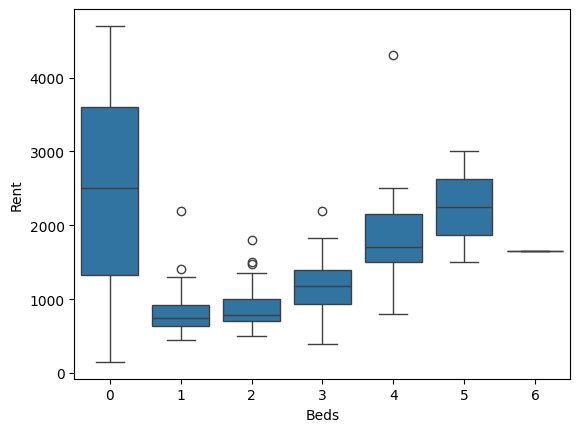

In [10]:
import seaborn as sns
sns.boxplot(data=df, x='Beds', y='Rent')

# Rent increases with Beds size

In [11]:
df.Baths.unique()

array([2.5, 1.5, 2. , 1. , 4.5, 3.5, 3. ])

<Axes: xlabel='Baths', ylabel='Rent'>

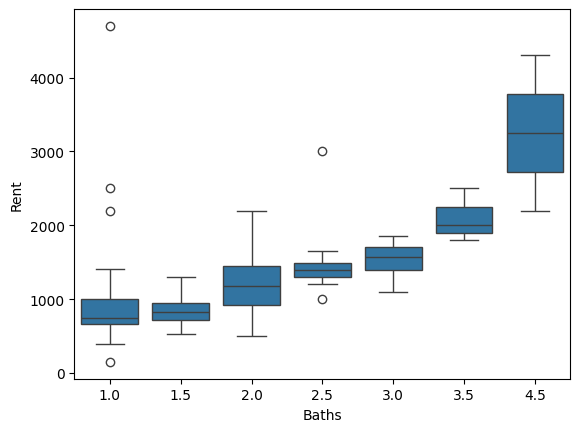

In [12]:
sns.boxplot(data=df, x='Baths', y='Rent')
#Rent is increasing with bath size

In [13]:
df.columns

Index(['Uniq Id', 'Crawl Timestamp', 'Property Url', 'Address', 'City',
       'State', 'Zip', 'Rent', 'Beds', 'Baths', 'Sqft', 'Property Type',
       'Number Of Units', 'Current Rent Zestimate',
       'Current Zestimate Of Value Of Home', 'Days Listed And Contacts',
       'Most Recent Tax Assessed Value', 'Broker Manager Owner', 'Agent Name',
       'Phone Number', 'Source', 'Zpid', 'County', 'Latitude', 'Longitude'],
      dtype='object')

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:2242: UserWarning: Warning: converting a masked element to nan.
  dtype = np.min_scalar_type(value)
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:2249: UserWarning: Warning: converting a masked element to nan.
  data = np.asarray(value)
/usr/local/lib/python3.11/dist-packages/matplotlib/ticker.py:561: UserWarning: Warning: converting a masked element to nan.
  else fmt % arg)


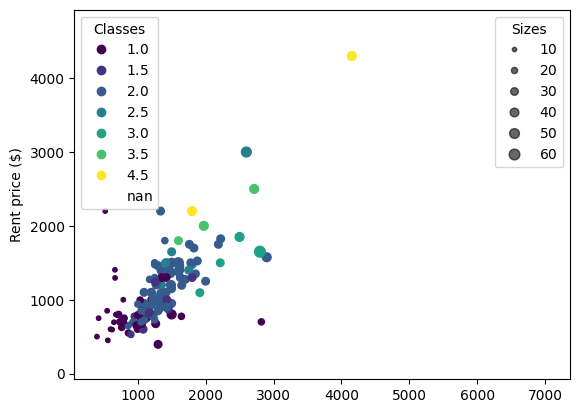

In [14]:
fig, ax = plt.subplots()
ax.set_ylabel('Rent price ($)')

scatter = ax.scatter(df.Sqft, df.Rent, s=df.Beds*10, c=df.Baths)

# produce a legend with the unique colors from the scatter
legend1 = ax.legend(*scatter.legend_elements(),
                    loc="upper left", title="Classes")
ax.add_artist(legend1)

# produce a legend with a cross-section of sizes from the scatter
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
legend2 = ax.legend(handles, labels, loc="upper right", title="Sizes")


#ax.set_ylim([0,6000])
plt.show()

In [37]:
# lets adjust a linear regression
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor



In [16]:
#First a simple linear regression

In [17]:
x=[df.Beds, df.Baths, df.Sqft]
y= df.Rent

x, y = np.array(x), np.array(y)

In [18]:
cols=['Beds', 'Baths', 'Sqft', 'Rent']
reg_df = df[cols]
# there are one row with na rent
complete_df = reg_df[-reg_df.isnull().any(axis=1)]

In [19]:
complete_df.shape

(137, 4)

In [20]:
x = complete_df.Sqft
y = complete_df.Rent

x, y = np.array(x).reshape((-1, 1)), np.array(y)

In [21]:
model = LinearRegression().fit(x, y)

In [22]:
r_sq = model.score(x, y)
print(f"coefficient of determination: {r_sq}")

coefficient of determination: 0.4571694610037088


In [23]:
print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")

intercept: 429.5315027932213
slope: [0.5256904]


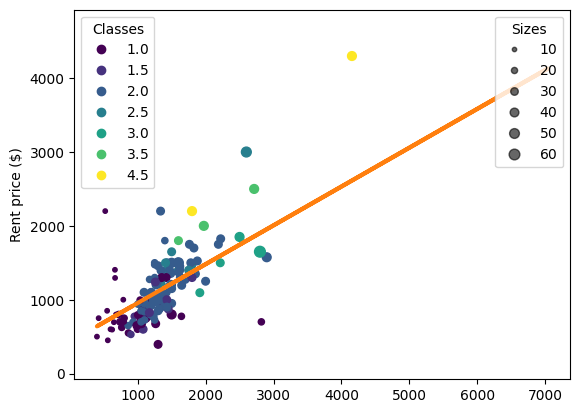

In [35]:
fig, ax = plt.subplots()
ax.set_ylabel('Rent price ($)')

scatter = ax.scatter(complete_df.Sqft, complete_df.Rent, s=complete_df.Beds*10
                     , c=complete_df.Baths)

# produce a legend with the unique colors from the scatter
legend1 = ax.legend(*scatter.legend_elements(),
                    loc="upper left", title="Classes")
ax.add_artist(legend1)

# produce a legend with a cross-section of sizes from the scatter
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
legend2 = ax.legend(handles, labels, loc="upper right", title="Sizes")

# add regresion line
y_pred = model.predict(x)
ax.plot(x, y_pred, linewidth=3, color="tab:orange", label="Model predictions")

plt.show()

In [25]:
# correlation matriz between independent variables and Rent Price
complete_df.corr()

,Beds,Baths,Sqft,Rent
Beds,1.000000,0.601106,0.173420,0.250754
Baths,0.601106,1.000000,0.325090,0.499942
Sqft,0.173420,0.325090,1.000000,0.676143
Rent,0.250754,0.499942,0.676143,1.000000


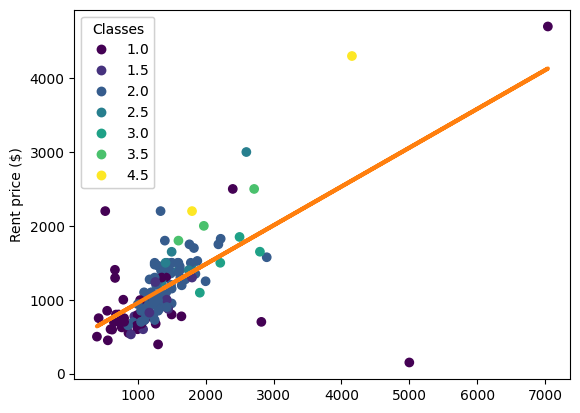

In [34]:
fig, ax = plt.subplots()
ax.set_ylabel('Rent price ($)')

scatter = ax.scatter(complete_df.Sqft, complete_df.Rent, c=complete_df.Baths)

# produce a legend with the unique colors from the scatter
legend1 = ax.legend(*scatter.legend_elements(),
                    loc="upper left", title="Classes")
ax.add_artist(legend1)
# add regresion line
y_pred = model.predict(x)
ax.plot(x, y_pred, linewidth=3, color="tab:orange", label="Model predictions")

plt.show()

In [50]:
# lets calculate the variance inflation factor to detect multicolinearity
# the independent variables set
X = complete_df[['Sqft', 'Baths', 'Beds']]

# VIF dataframe
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

print(vif_data)

  feature        VIF
0    Sqft   4.358360
1   Baths  12.644062
2    Beds  10.762088


In [ ]:
# Baths has a high correlation to Rent so we remove beds from regression

In [79]:
X = complete_df[['Sqft', 'Baths']]

# VIF dataframe
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

print(vif_data)

  feature      VIF
0    Sqft  4.28862
1   Baths  4.28862


In [ ]:
# VIF is not high now

In [81]:
# now we adjust a multiple linear regression
X = complete_df[["Sqft", "Baths",]]
y = complete_df.Rent

X, y = np.array(X), np.array(y)

In [82]:
multiple_model = LinearRegression().fit(X, y)

In [83]:
# r_sqrt is higher than with just one variable

r_sq = multiple_model.score(X, y)
print(f"coefficient of determination: {r_sq}")

print(f"intercept: {multiple_model.intercept_}")

print(f"coefficients: {multiple_model.coef_}")

coefficient of determination: 0.544918560930699
intercept: 35.94684123479897
coefficients: [  0.44651857 281.08954556]


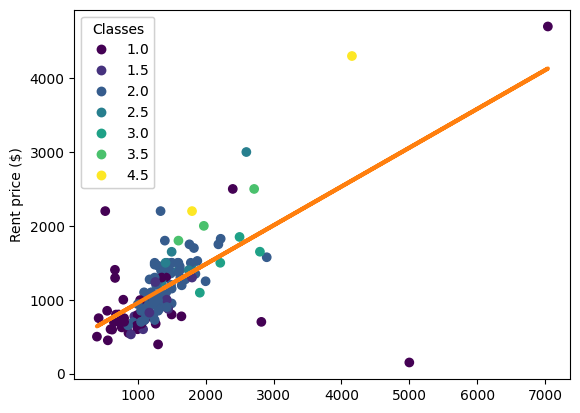

In [80]:
fig, ax = plt.subplots()
ax.set_ylabel('Rent price ($)')

scatter = ax.scatter(complete_df.Sqft, complete_df.Rent, c=complete_df.Baths)

# produce a legend with the unique colors from the scatter
legend1 = ax.legend(*scatter.legend_elements(),
                    loc="upper left", title="Classes")
ax.add_artist(legend1)
# add regresion line
y_pred = model.predict(x)
ax.plot(x, y_pred, linewidth=3, color="tab:orange", label="Model predictions")

plt.show()

In [89]:
# lets check regression assumptions
predictions = multiple_model.predict(X)
df_predictions = pd.DataFrame({"Actual" : complete_df.Rent, "Prediction" : predictions})
df_predictions["Residuals"] = abs(df_predictions.Actual) - abs(df_predictions.Prediction)

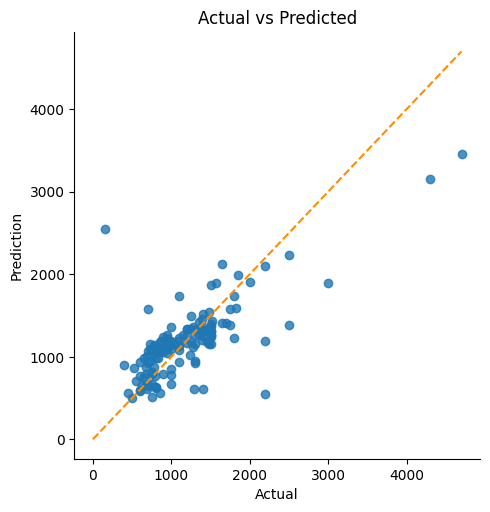

In [104]:
#Plotting actual vs predicted values
sns.lmplot(x = "Actual", y = "Prediction", data=df_predictions, fit_reg=False)

# plotting identity line
line_coords = np.arange(0, df_predictions.max().max())
plt.plot(line_coords, line_coords, color = "darkorange", linestyle= "--")
plt.title("Actual vs Predicted")
plt.show()

In [113]:
from statsmodels.stats.diagnostic import normal_ad
#Perform Anderson-Darling to test if residuals are distributed normally
# p value is less than threshold so residuals are not normally distributed
p_value = normal_ad(df_predictions['Residuals'])[1]
p_value

np.float64(2.661158504151963e-13)

<Axes: title={'center': 'Distribution of residuals'}, xlabel='Residuals', ylabel='Density'>

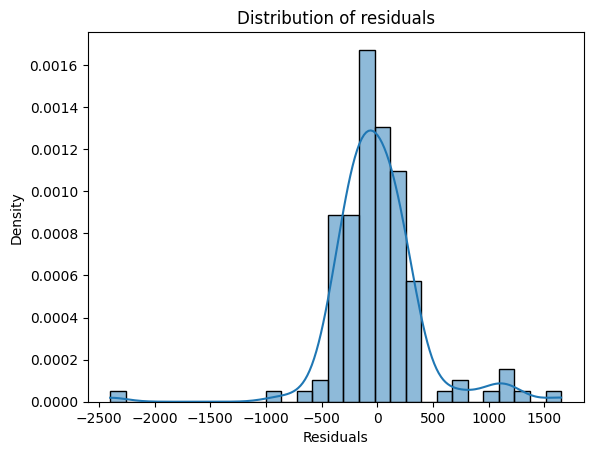

In [112]:
# Plotting residual dist.
plt.title('Distribution of residuals')
sns.histplot(df_predictions['Residuals'], kde=True, stat="density")

In [116]:
# test for autocorrelation
# durbin watson statistic is greater than 1.5 so there is no autocorrelation
from statsmodels.stats.stattools import durbin_watson

durbinWatson = durbin_watson(df_predictions['Residuals'])
durbinWatson

np.float64(2.0560430784319874)

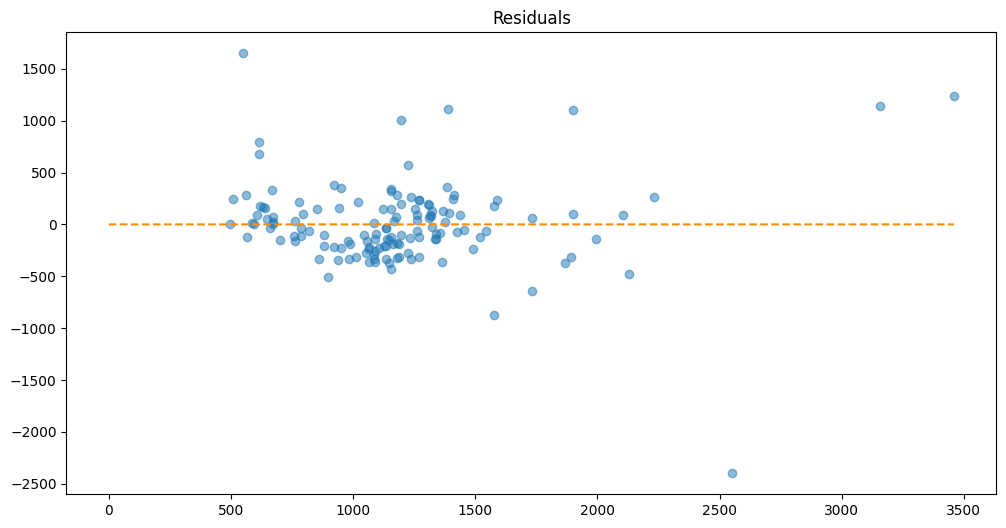

In [121]:
# test for homoscedasticity
# From the ressidual plot we cannot conclude that residuals are heteroskedastic

plt.subplots(figsize=(12,6))
plt.subplot(111)
plt.scatter(x=df_predictions.Prediction, y=df_predictions.Residuals, alpha = 0.5)
plt.plot(np.repeat(0, df_predictions.Prediction.max()), color='darkorange', linestyle="--")
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.title('Residuals')
plt.show()

In [151]:
from statsmodels.stats.diagnostic import het_white
from statsmodels.compat import lzip
import statsmodels.api as sm
import statsmodels.stats.api as sms

In [149]:
#White test
# Data p-value < 0.05 H0: Data is homoscedastic is rejected

white_test = het_white(df_predictions.Residuals, exog = sm.add_constant(X) )
#Zipping the array with labels
names = ['Lagrange multiplier statistic', 'p-value','f-value', 'f p-value']
lzip(names,white_test)

[('Lagrange multiplier statistic', np.float64(51.017839450126175)),
 ('p-value', np.float64(8.576255708945074e-10)),
 ('f-value', np.float64(15.545868876113827)),
 ('f p-value', np.float64(5.4260673329383075e-12))]

In [154]:
# Another homoscedasticity test consistent to White test
test_result = sms.het_breuschpagan(df_predictions.Residuals, sm.add_constant(X))

lzip(names, test_result)

[('Lagrange multiplier statistic', np.float64(48.22769527897144)),
 ('p-value', np.float64(3.368907080974499e-11)),
 ('f-value', np.float64(36.39936570133523)),
 ('f p-value', np.float64(2.3676318976304495e-13))]